# Compare yields $16$ fb$^{-1}$ $4$ fb$^{-1}$
## Check that the single- and double-tag yields between the two datasets are compatible

### Integrated luminosities

In [1]:
const std::map<std::string, std::pair<double, double> > IntLumi{
    {"No2024", std::pair<double, double>{16.082, 0.039}},
    {"Only2024", std::pair<double, double>{4.191, 0.016}},
    {"Only2022", std::pair<double, double>{4.995, 0.019}},
    {"OnlyOld", std::pair<double, double>{2.932, 0.014}}
};

### Functions for parsing fit results

In [2]:
std::map<std::string, double> ParseFitResults(const std::string &Filename) {
    std::map<std::string, double> FitResults;
    std::ifstream File(Filename);
    std::string Line;
    while(std::getline(File, Line)) {
        if(Line.empty() || Line[0] == '*') {
            continue;
        }
        std::stringstream ss(Line);
        std::string Name;
        double Value;
        ss >> Name >> Value;
        FitResults.insert({Name, Value});
    }
    return FitResults;
}

In [3]:
std::map<std::string, double> ParseFitResults(const std::string &Tag,
                                              const std::string &STorDT,
                                              const std::string &Dataset) {
    std::string Filename("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_20fb_");
    Filename += Dataset;
    if(STorDT == "ST") {
        Filename += "/SingleTagFit/" + Tag + "/";
        Filename += Tag + "_MBC_FitResults.txt";
    } else if(STorDT == "DT") {
        Filename += "/DoubleTagFit/" + Tag + "/";
        Filename += "KKpipi_vs_" + Tag + "_SignalYield.txt";
    } else {
        std::cout << "Something's wrong\n";
    }
    return ParseFitResults(Filename);
}

### Function for parsing all ST yields, and divide by luminosity

In [4]:
std::pair<std::vector<double>, std::vector<double> > ParseSTYields(const std::string Dataset,
                                                                   const std::vector<std::string> &ST_tags) {
    std::vector<double> STYields, STYields_err;
    for(const std::string &Tag : ST_tags) {
        const auto Results = ParseFitResults(Tag, "ST", Dataset);
        STYields.push_back(Results.at(Tag + "_SingleTag_Yield"));
        STYields_err.push_back(Results.at(Tag + "_SingleTag_Yield_err"));
    }
    double RelLumi_err = IntLumi.at(Dataset).second/IntLumi.at(Dataset).first;
    STYields_err.back() = TMath::Sqrt(TMath::Power(STYields_err.back(), 2)
                                    + TMath::Power(RelLumi_err, 2)*STYields.back());
    std::transform(STYields.begin(),
                   STYields.end(),
                   STYields.begin(),
                   [&](double a) {return a/IntLumi.at(Dataset).first;});
    std::transform(STYields_err.begin(),
                   STYields_err.end(),
                   STYields_err.begin(),
                   [&](double a) {return a/IntLumi.at(Dataset).first;});
    return std::make_pair(STYields, STYields_err);
}

### Plot a comparison of ST yields

In [5]:
void CompareSTYields(const std::vector<std::string> &ST_tags,
                     const std::string &Filename) {
    const std::size_t N = ST_tags.size();
    const auto No2024Yields = ParseSTYields("No2024", ST_tags);
    const auto Only2024Yields = ParseSTYields("Only2024", ST_tags);
    const auto Only2022Yields = ParseSTYields("Only2022", ST_tags);
    const auto OnlyOldYields = ParseSTYields("OnlyOld", ST_tags);
    std::vector<double> index1(N), index2(N), index3(N), index4(N);
    std::iota(index1.begin(), index1.end(), 0.06);
    std::iota(index2.begin(), index2.end(), 0.10);
    std::iota(index3.begin(), index3.end(), 0.14);
    std::iota(index4.begin(), index4.end(), 0.18);
    TGraphErrors *No2024_graph = new TGraphErrors(
        N, index1.data(), No2024Yields.first.data(),
        nullptr, No2024Yields.second.data());
    TGraphErrors *Only2024_graph = new TGraphErrors(
        N, index2.data(), Only2024Yields.first.data(),
        nullptr, Only2024Yields.second.data());
    TGraphErrors *Only2022_graph = new TGraphErrors(
        N, index3.data(), Only2022Yields.first.data(),
        nullptr, Only2022Yields.second.data());
    TGraphErrors *OnlyOld_graph = new TGraphErrors(
        N, index4.data(), OnlyOldYields.first.data(),
        nullptr, OnlyOldYields.second.data());
    No2024_graph->SetLineWidth(3);
    No2024_graph->SetLineColor(kBlack);
    Only2024_graph->SetLineWidth(3);
    Only2024_graph->SetLineColor(kBlue);
    Only2022_graph->SetLineWidth(3);
    Only2022_graph->SetLineColor(kRed);
    OnlyOld_graph->SetLineWidth(3);
    OnlyOld_graph->SetLineColor(kMagenta);
    std::string Title = ST_tags[0];
    for(std::size_t i = 1; i < N; i++) {
        Title += "     " + ST_tags[i];
    }
    Title += ";Tag;Yield/fb^{-1}";
    No2024_graph->SetTitle(Title.c_str());
    static std::size_t Counter = 0;
    TCanvas *c = new TCanvas(("c_" + std::to_string(Counter++)).c_str(), "",
                             1200, 900);
    No2024_graph->Draw("AP E1");
    Only2024_graph->Draw("P E1 same");
    Only2022_graph->Draw("P E1 same");
    //OnlyOld_graph->Draw("P E1 same");
    c->Draw();
    c->SaveAs(Filename.c_str());
}

In [6]:
const std::vector<std::string> ST_tags1{
    "KKpipi", "KSeta", "KSetaPrimepipieta", "KSetaPrimerhogamma", "KSpi0pi0", "pipi"
};
const std::vector<std::string> ST_tags2{
    "KSpi0", "KK"
};
const std::vector<std::string> ST_tags3{
    "Kpi", "Kpipi0", "Kpipipi"
};
const std::vector<std::string> ST_tags4{
    "KSpipi", "KSpipipi0", "pipipi0"
};

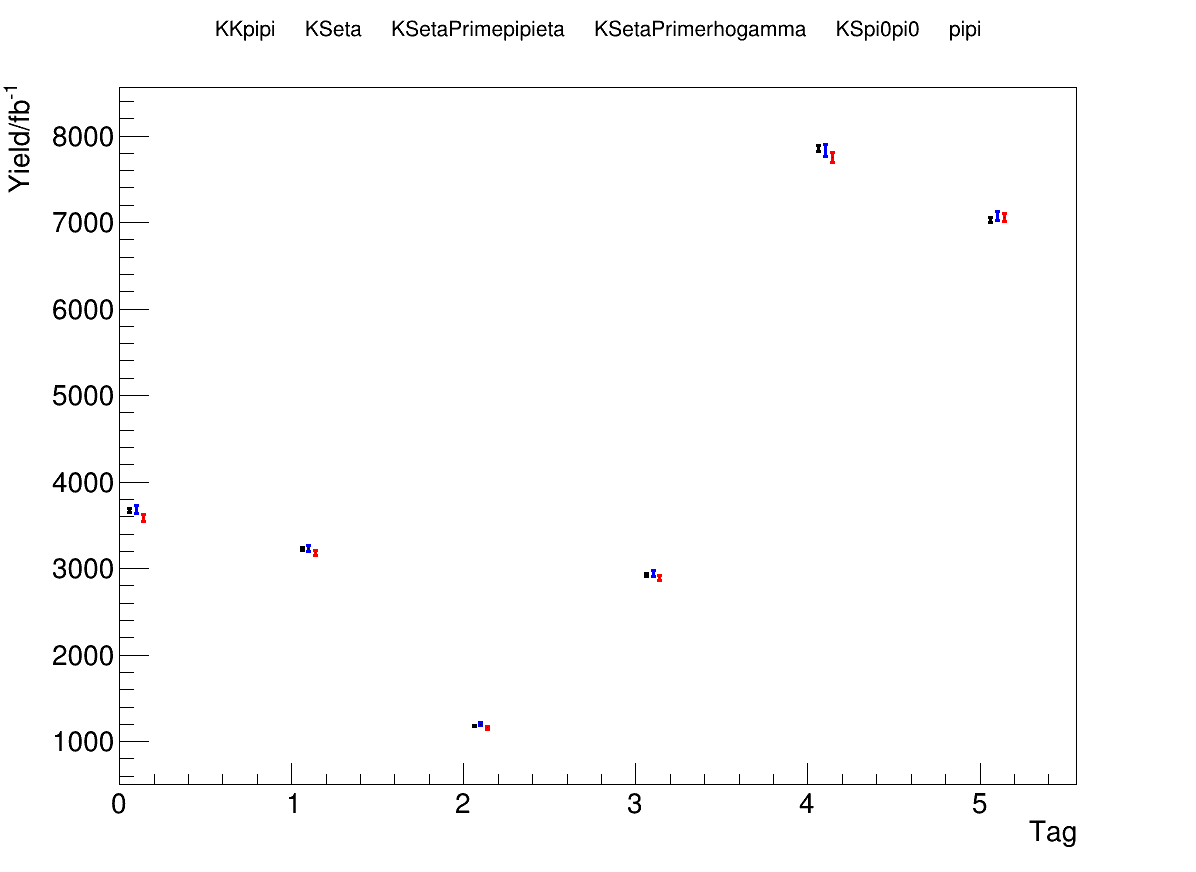

Info in <TCanvas::Print>: pdf file ST_yield_comparison_16_4_Batch1.pdf has been created


In [7]:
CompareSTYields(ST_tags1, "ST_yield_comparison_16_4_Batch1.pdf");

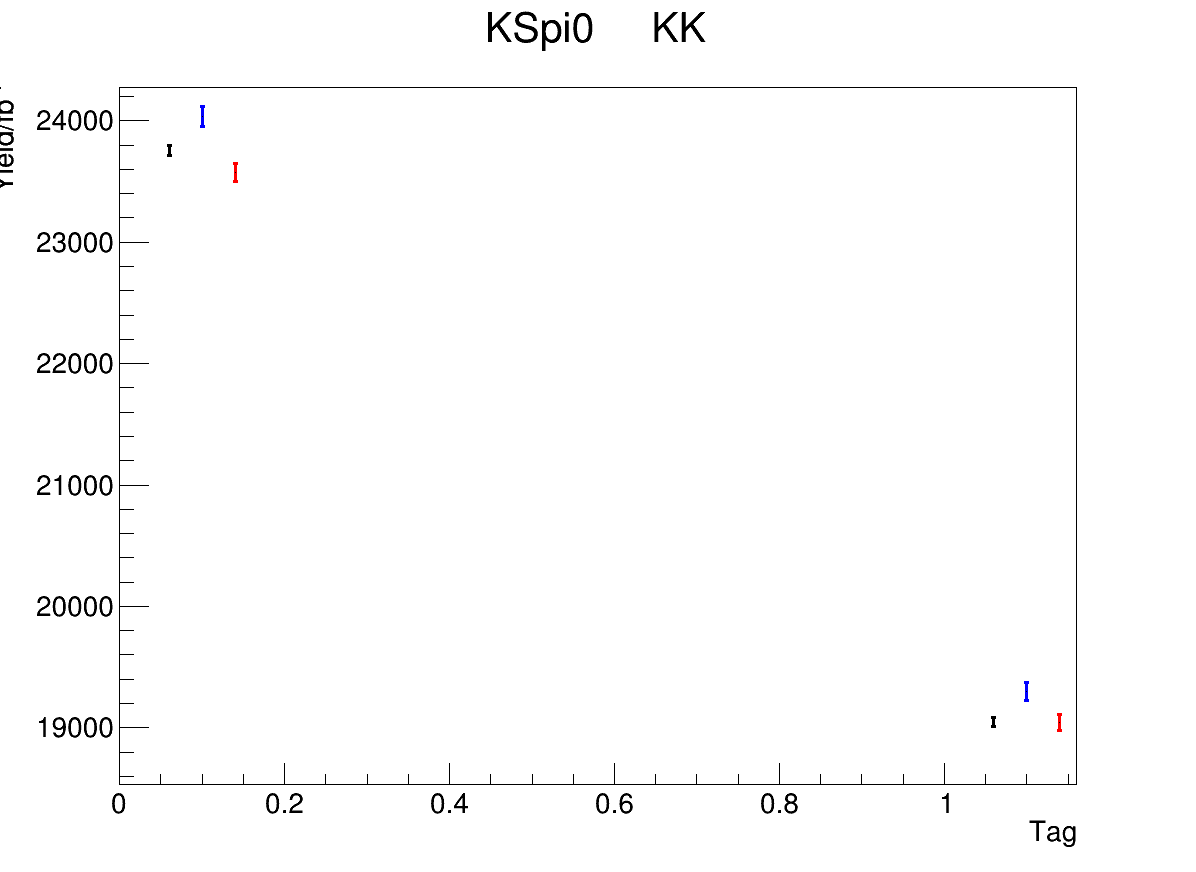

Info in <TCanvas::Print>: pdf file ST_yield_comparison_16_4_Batch2.pdf has been created


In [8]:
CompareSTYields(ST_tags2, "ST_yield_comparison_16_4_Batch2.pdf");

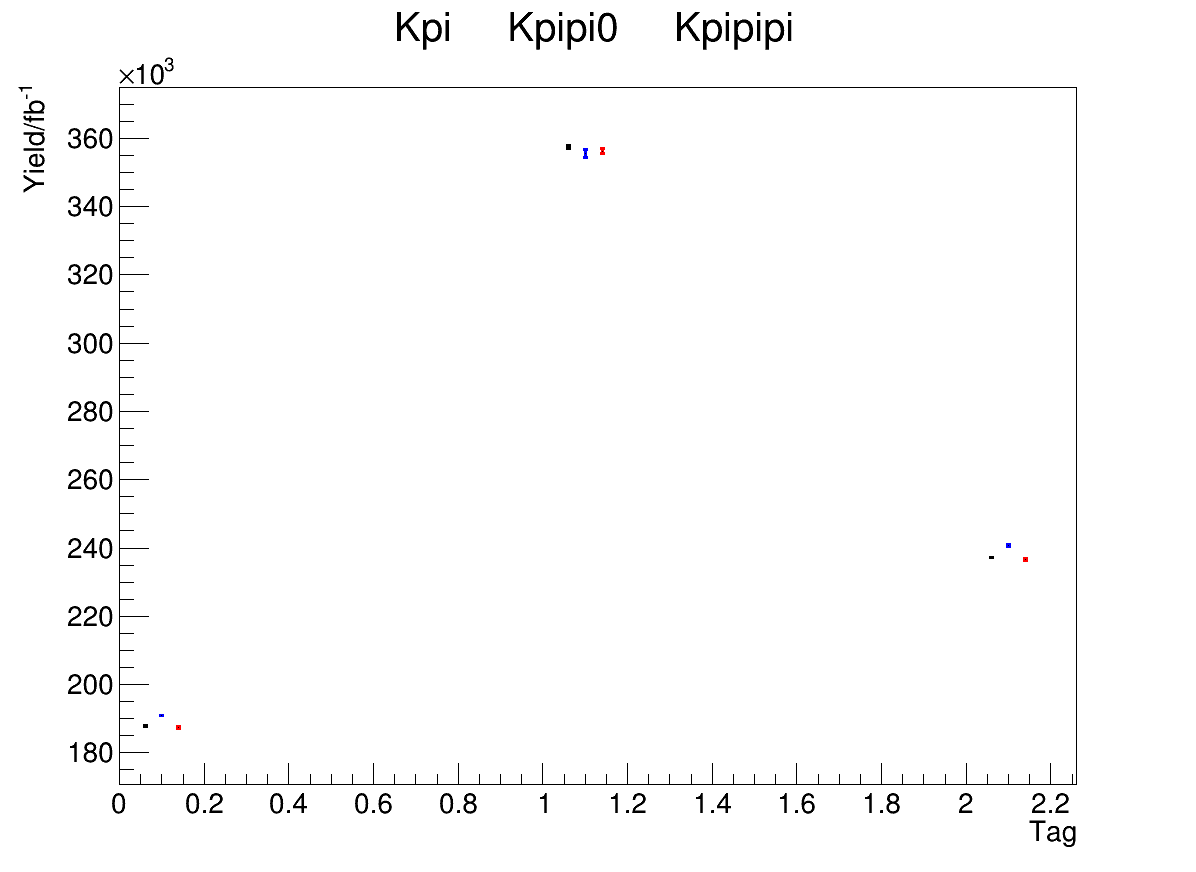

Info in <TCanvas::Print>: pdf file ST_yield_comparison_16_4_Batch3.pdf has been created


In [9]:
CompareSTYields(ST_tags3, "ST_yield_comparison_16_4_Batch3.pdf");

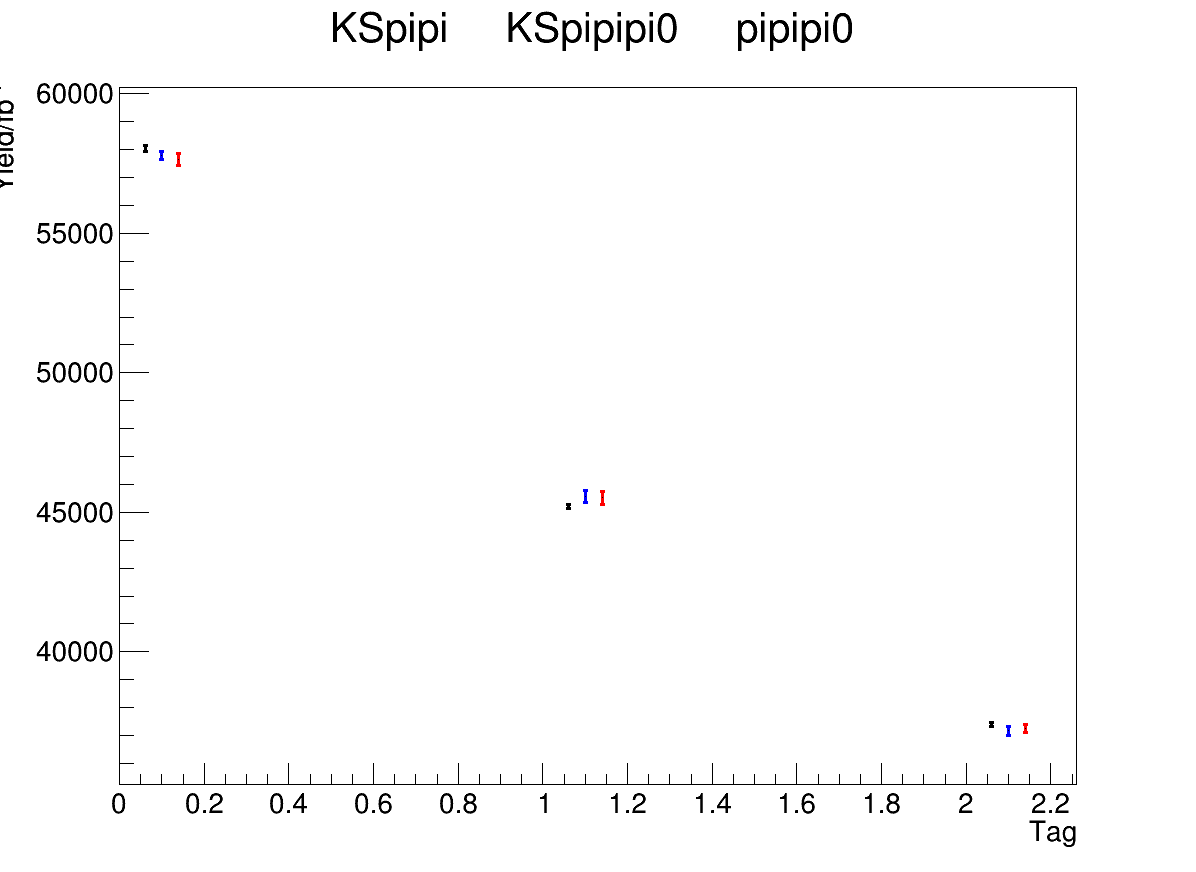

Info in <TCanvas::Print>: pdf file ST_yield_comparison_16_4_Batch4.pdf has been created


In [10]:
CompareSTYields(ST_tags4, "ST_yield_comparison_16_4_Batch4.pdf");

### Compare DT yields

In [11]:
std::pair<std::vector<double>, std::pair<std::vector<double>, std::vector<double> > >
    ParseDTYields(const std::string Dataset,
                  const std::string &Tag,
                  const std::string &TagType) {
    std::vector<double> DTYields, DTYields_lerr, DTYields_uerr;
    const auto Results = ParseFitResults(Tag, "DT", Dataset);
    for(int SignalBin = -4; SignalBin <= 4; SignalBin++) {
        if(SignalBin == 0) {
            continue;
        }
        if(TagType == "CP" && SignalBin < 0) {
            continue;
        }
        std::string VarName("DoubleTag_");
        VarName += TagType + "_KKpipi_vs_" + Tag + "_SignalBin";
        if(TagType != "CP") {
            VarName += SignalBin > 0 ? "P" : "M";
        }
        VarName += std::to_string(TMath::Abs(SignalBin));
        
        for(std::size_t TagBin = 1; TagBin <= 8; TagBin++) {
            std::string VarName2 = VarName;
            if(TagType != "SCMB" && TagBin > 1) {
                continue;
            }
            if(TagType == "SCMB") {
                VarName2 += "_TagBin" + std::to_string(TagBin);
            }
            if(TagType == "Flavour") {
                VarName2 += "_TagBin0";
            }
            VarName2 += "_SignalYield";
            DTYields.push_back(Results.at(VarName2)/IntLumi.at(Dataset).first);
            DTYields_lerr.push_back(-Results.at(VarName2 + "_low_err")/IntLumi.at(Dataset).first);
            DTYields_uerr.push_back(Results.at(VarName2 + "_high_err")/IntLumi.at(Dataset).first);
        }
    }
    std::pair<std::vector<double>, std::vector<double> > err{DTYields_lerr, DTYields_uerr};
    return std::make_pair(DTYields, err);

}

In [12]:
void CompareDTYields(const std::string &Tag,
                     const std::string &TagType,
                     double Minimum = -999.0, double Maximum = -999.0) {
    const auto No2024Yields = ParseDTYields("No2024", Tag, TagType);
    const auto Only2024Yields = ParseDTYields("Only2024", Tag, TagType);
    const auto Only2022Yields = ParseDTYields("Only2022", Tag, TagType);
    const auto OnlyOldYields = ParseDTYields("OnlyOld", Tag, TagType);
    const std::size_t N = No2024Yields.first.size();
    std::vector<double> index1(N), index2(N), index3(N), index4(N);
    std::iota(index1.begin(), index1.end(), 0.06);
    std::iota(index2.begin(), index2.end(), 0.10);
    std::iota(index3.begin(), index3.end(), 0.14);
    std::iota(index4.begin(), index4.end(), 0.18);
    auto *No2024_graph = new TGraphAsymmErrors(
        N, index1.data(), No2024Yields.first.data(),
        nullptr, nullptr,
        No2024Yields.second.first.data(),
        No2024Yields.second.second.data());
    auto *Only2024_graph = new TGraphAsymmErrors(
        N, index2.data(), Only2024Yields.first.data(),
        nullptr, nullptr,
        Only2024Yields.second.first.data(),
        Only2024Yields.second.second.data());
    auto *Only2022_graph = new TGraphAsymmErrors(
        N, index3.data(), Only2022Yields.first.data(),
        nullptr, nullptr,
        Only2022Yields.second.first.data(),
        Only2022Yields.second.second.data());
    auto *OnlyOld_graph = new TGraphAsymmErrors(
        N, index4.data(), OnlyOldYields.first.data(),
        nullptr, nullptr,
        OnlyOldYields.second.first.data(),
        OnlyOldYields.second.second.data());
    No2024_graph->SetLineWidth(3);
    No2024_graph->SetLineColor(kBlack);
    No2024_graph->SetMarkerStyle(8);
    No2024_graph->SetMarkerColor(kBlack);
    Only2024_graph->SetLineWidth(3);
    Only2024_graph->SetLineColor(kBlue);
    Only2024_graph->SetMarkerStyle(8);
    Only2024_graph->SetMarkerColor(kBlue);
    Only2022_graph->SetLineWidth(3);
    Only2022_graph->SetLineColor(kRed);
    Only2022_graph->SetMarkerStyle(8);
    Only2022_graph->SetMarkerColor(kRed);
    OnlyOld_graph->SetLineWidth(3);
    OnlyOld_graph->SetLineColor(kMagenta);
    OnlyOld_graph->SetMarkerStyle(8);
    OnlyOld_graph->SetMarkerColor(kMagenta);
    std::string Title = Tag + ";Bin;Yield/fb^{-1}";
    No2024_graph->SetTitle(Title.c_str());
    if(Minimum > -999.0) {
        No2024_graph->SetMinimum(Minimum);
    }
    if(Maximum > -999.0) {
        No2024_graph->SetMaximum(Maximum);
    }    
    static std::size_t Counter = 0;
    TCanvas *c = new TCanvas(("c_" + std::to_string(Counter++)).c_str(), "",
                             1200, 900);
    No2024_graph->Draw("AP E1");
    Only2024_graph->Draw("P E1 same");
    Only2022_graph->Draw("P E1 same");
    OnlyOld_graph->Draw("P E1 same");
    c->Draw();
    c->SaveAs(("DT_yield_comparison_16_4_" + Tag + ".pdf").c_str());
}

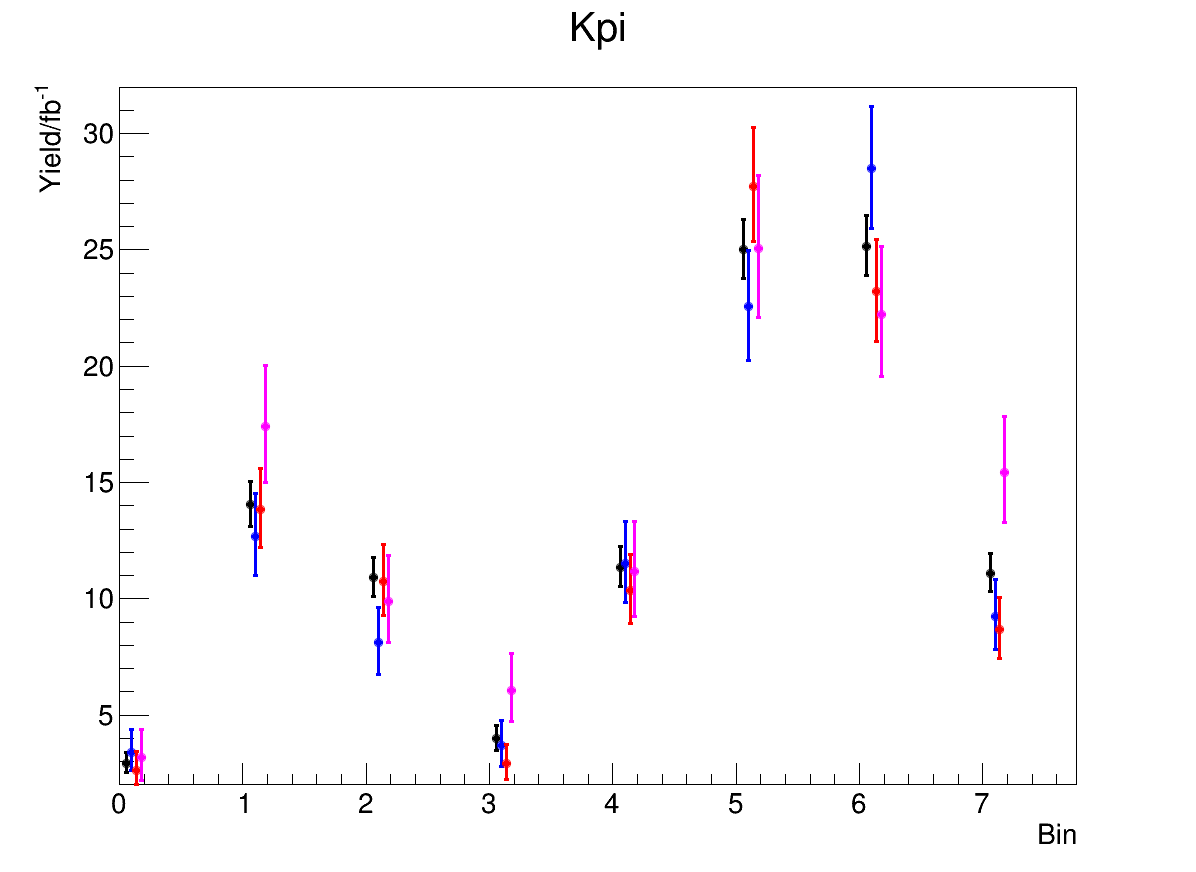

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_0
Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_Kpi.pdf has been created


In [13]:
CompareDTYields("Kpi", "Flavour", 2.0, 32.0);

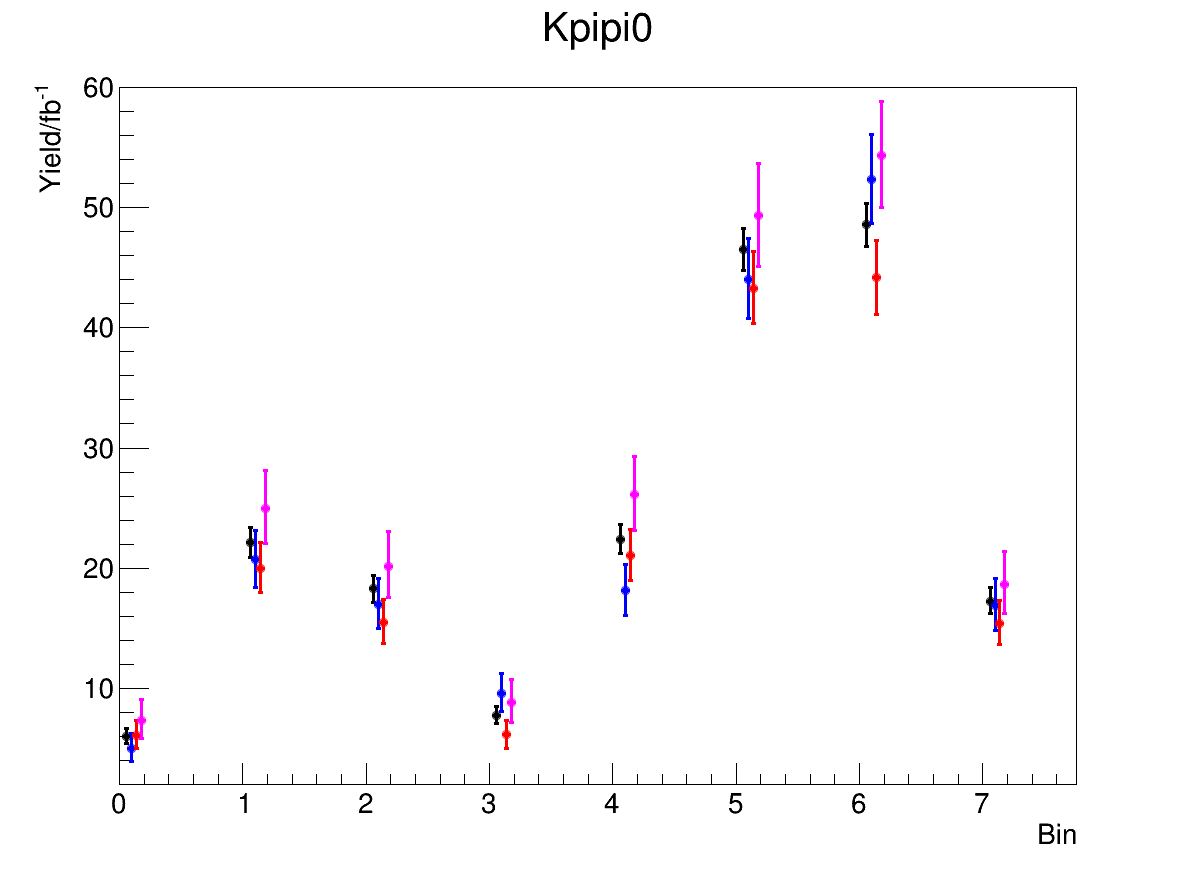

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_1
Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_Kpipi0.pdf has been created


In [14]:
CompareDTYields("Kpipi0", "Flavour", 2.0, 60.0);

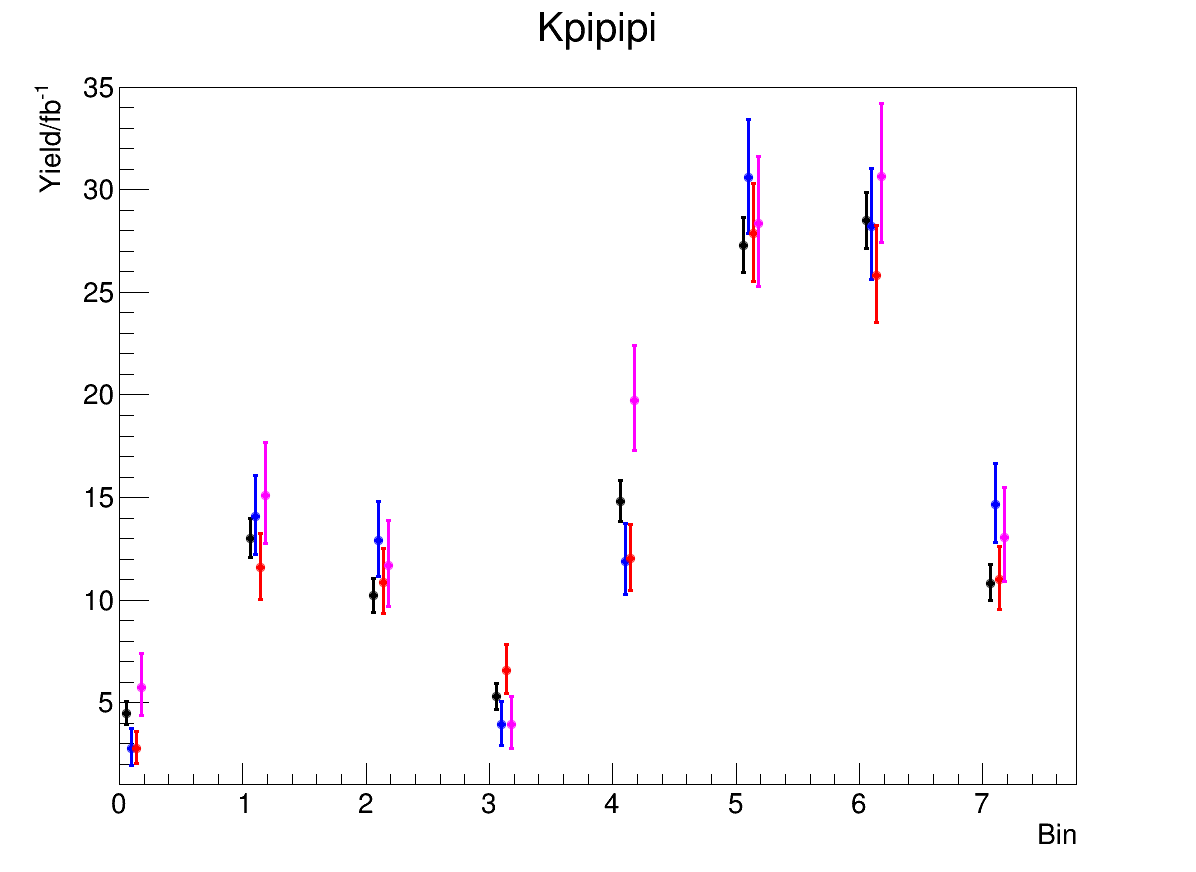

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_2
Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_Kpipipi.pdf has been created


In [15]:
CompareDTYields("Kpipipi", "Flavour", 1.0, 35.0);

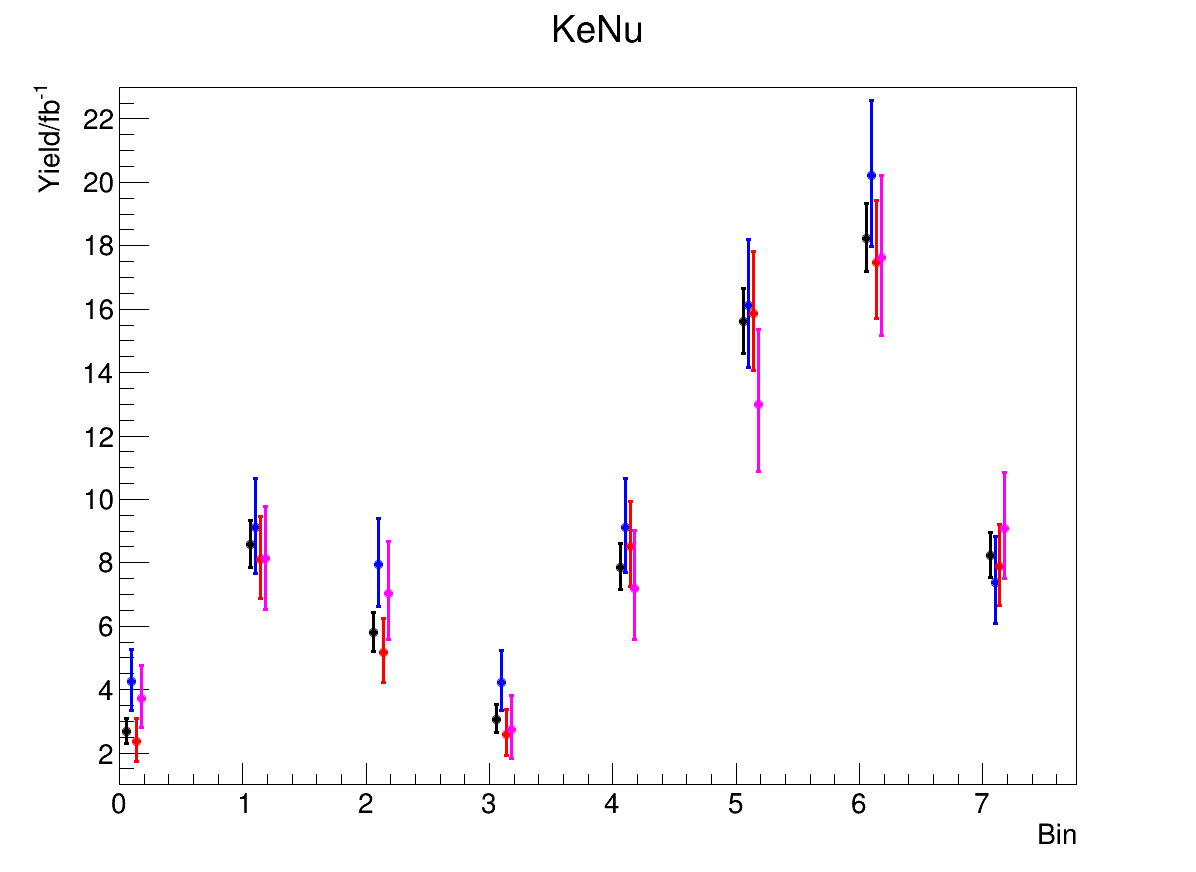

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_3
Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KeNu.pdf has been created


In [16]:
CompareDTYields("KeNu", "Flavour", 1.0, 23.0);

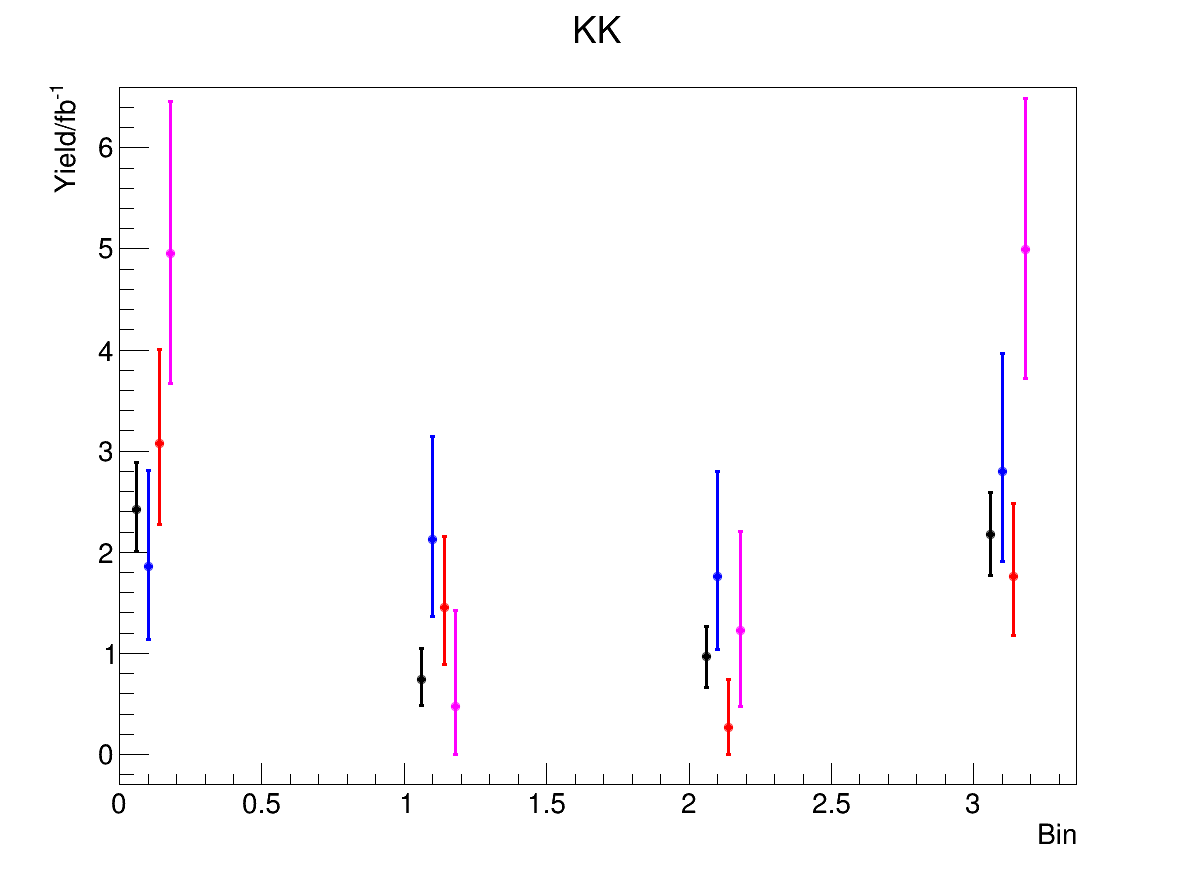

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KK.pdf has been created


In [32]:
CompareDTYields("KK", "CP", -0.3, 6.6);

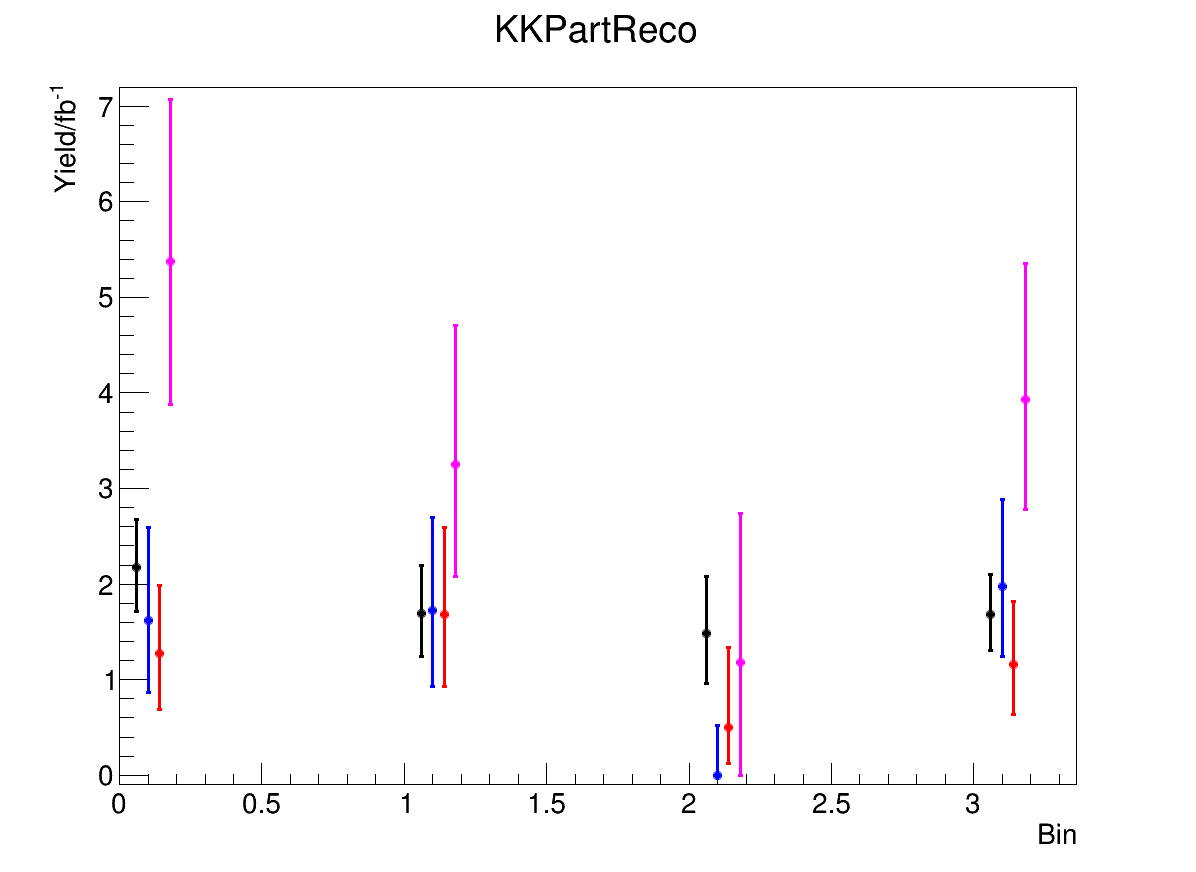

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KKPartReco.pdf has been created


In [35]:
CompareDTYields("KKPartReco", "CP", -0.1, 7.2);

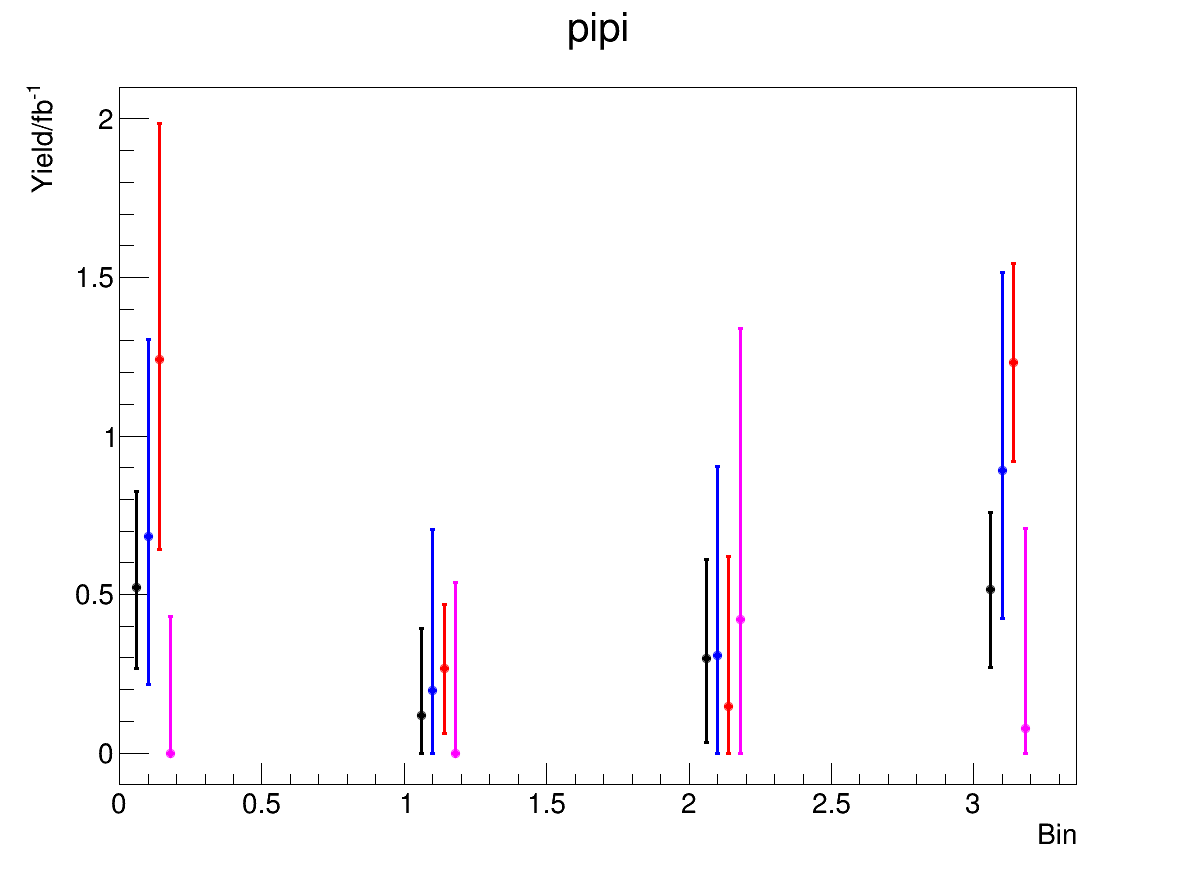

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_pipi.pdf has been created


In [19]:
CompareDTYields("pipi", "CP", -0.1, 2.1);

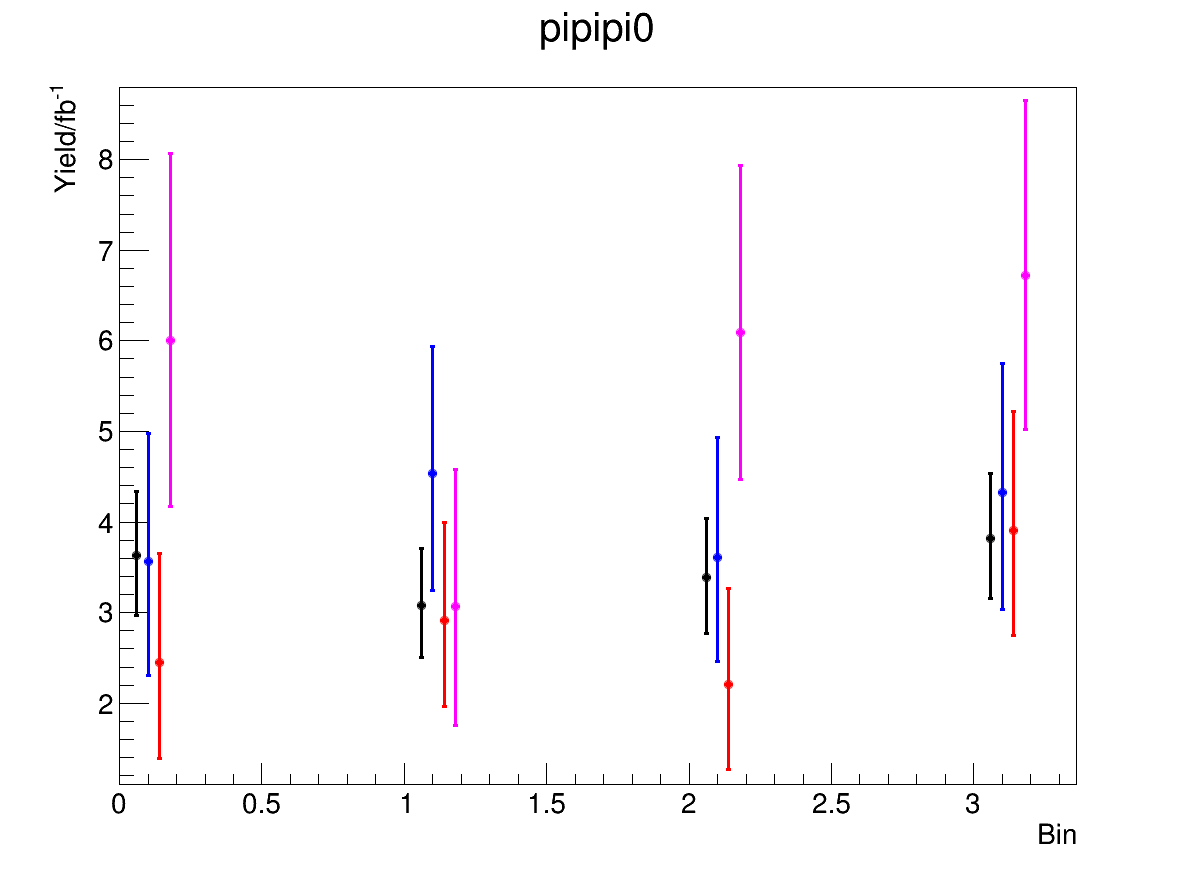

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_pipipi0.pdf has been created


In [20]:
CompareDTYields("pipipi0", "CP", 1.1, 8.8);

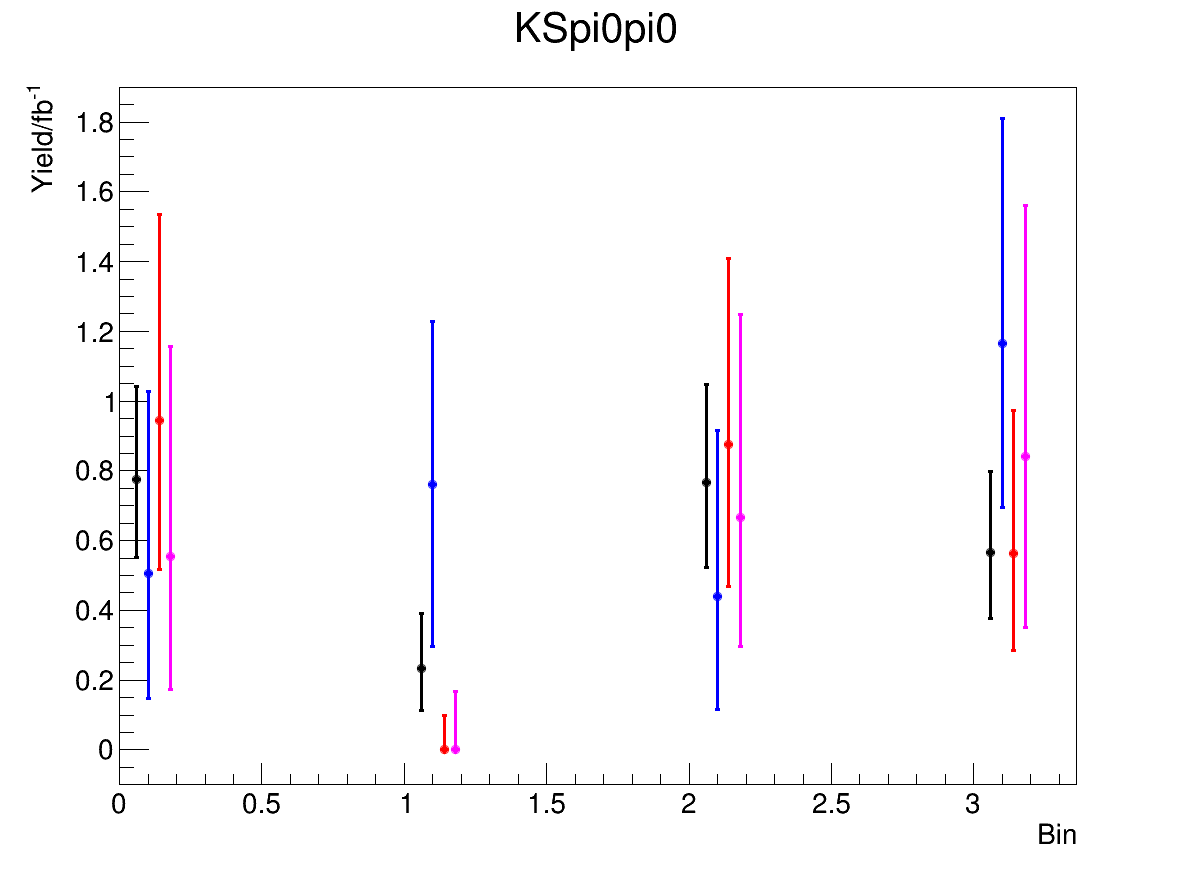

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSpi0pi0.pdf has been created


In [21]:
CompareDTYields("KSpi0pi0", "CP", -0.1, 1.9);

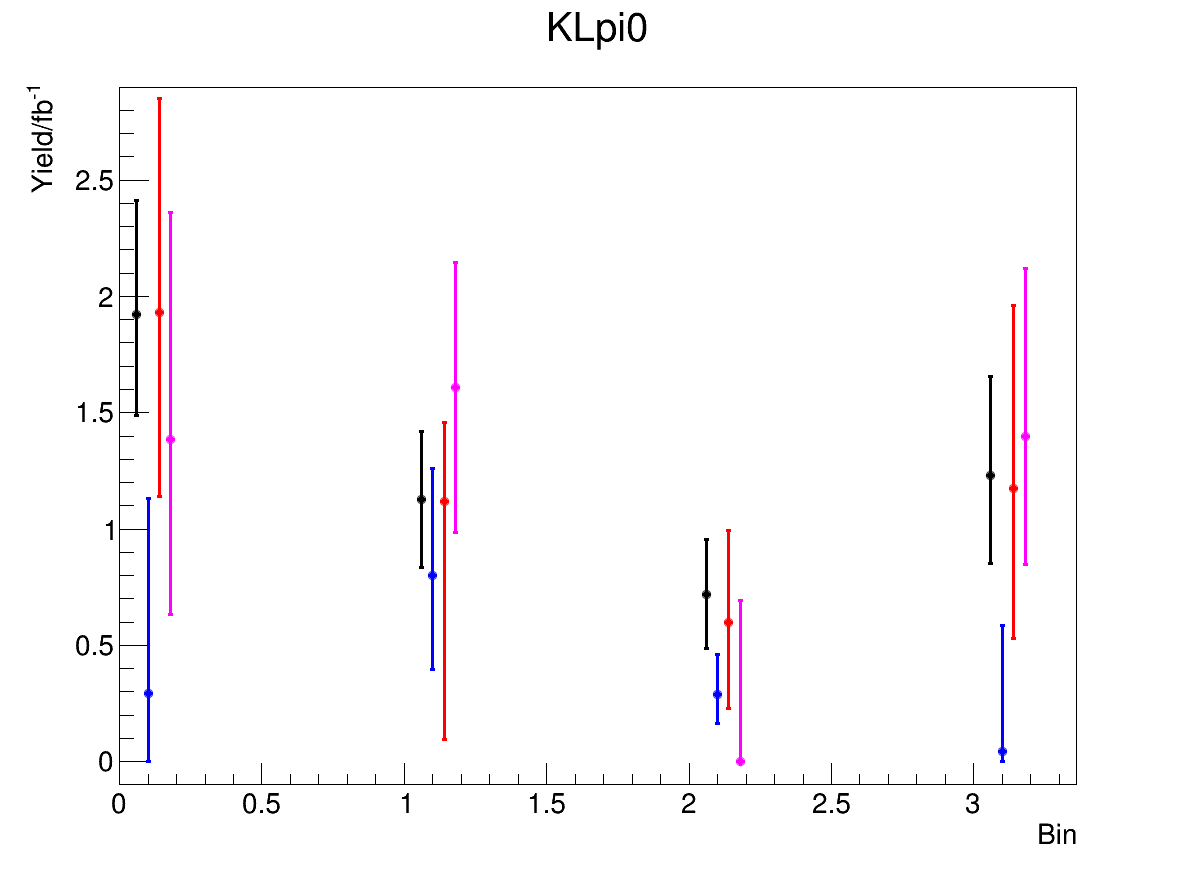

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KLpi0.pdf has been created


In [22]:
CompareDTYields("KLpi0", "CP", -0.1, 2.9);

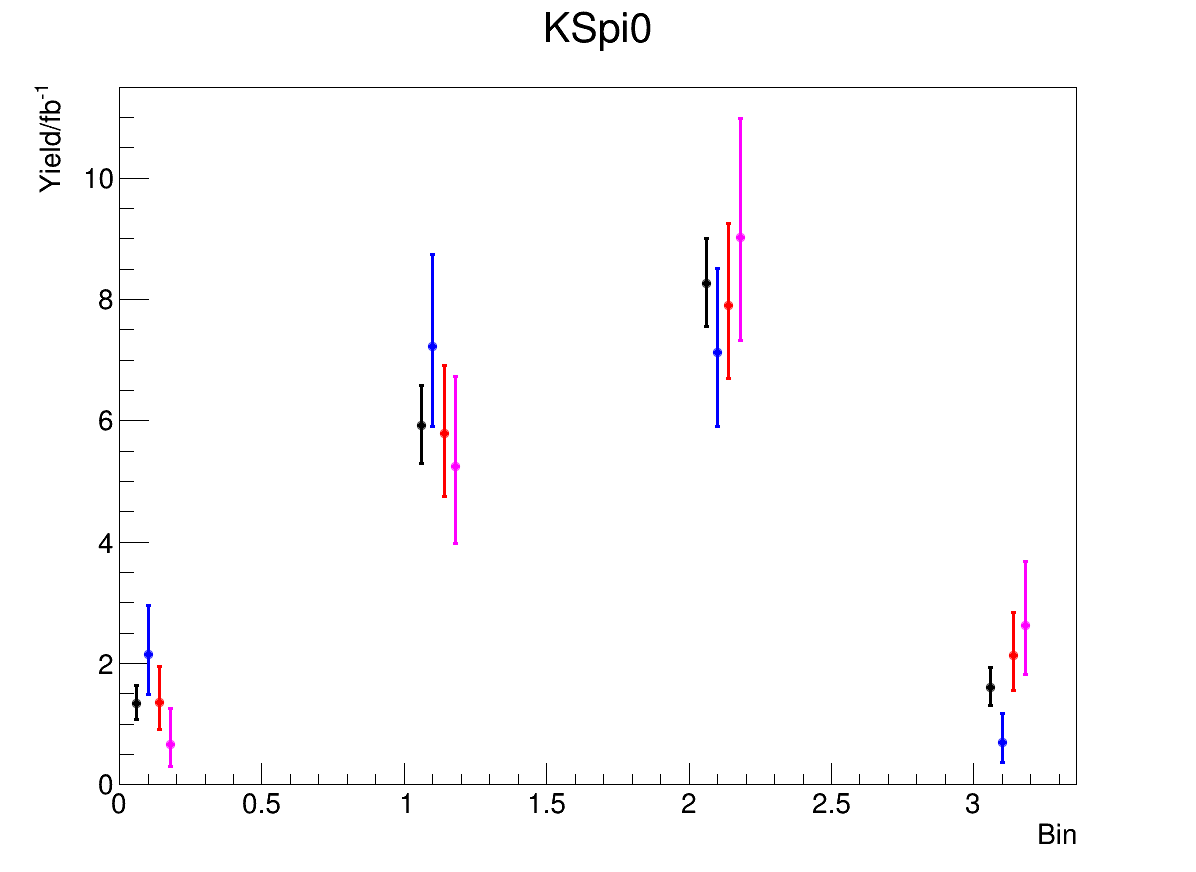

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSpi0.pdf has been created


In [23]:
CompareDTYields("KSpi0", "CP", 0.0, 11.5);

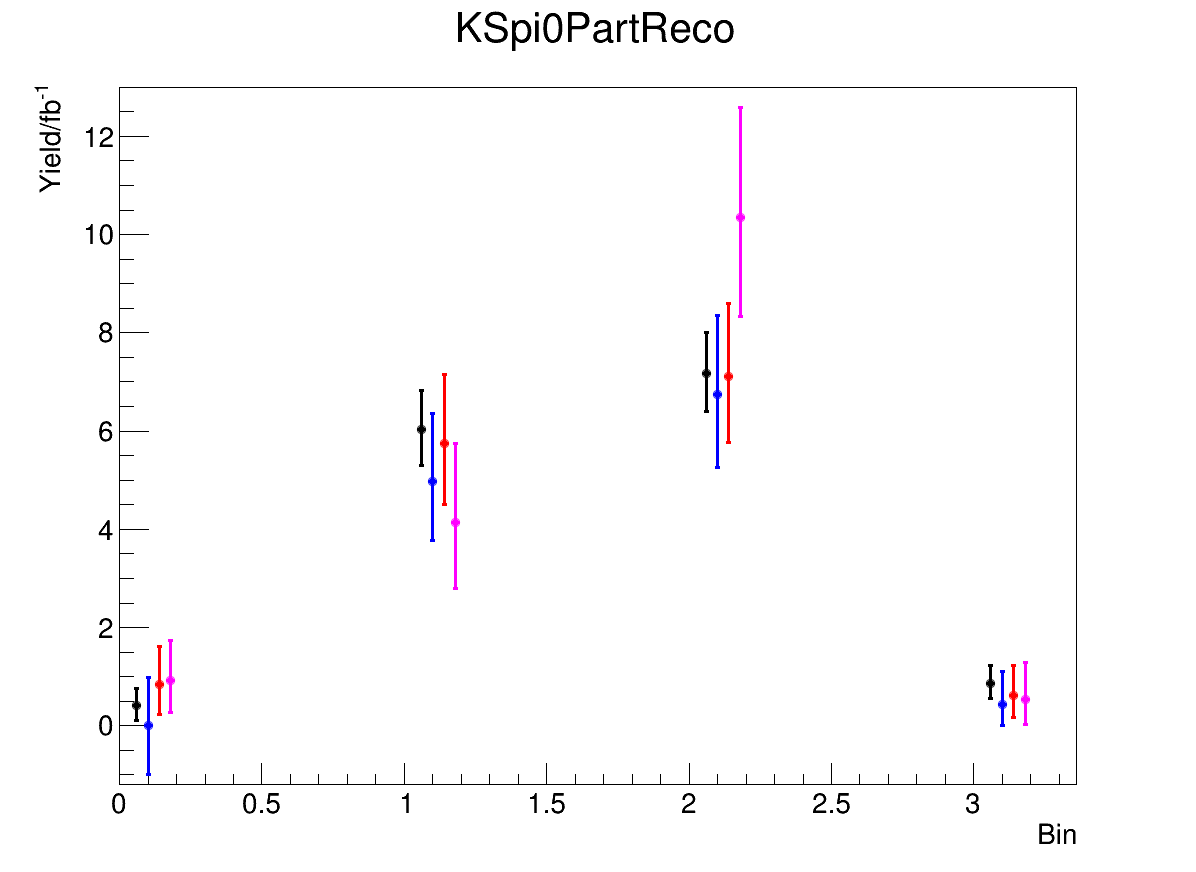

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSpi0PartReco.pdf has been created


In [24]:
CompareDTYields("KSpi0PartReco", "CP", -1.2, 13.0);

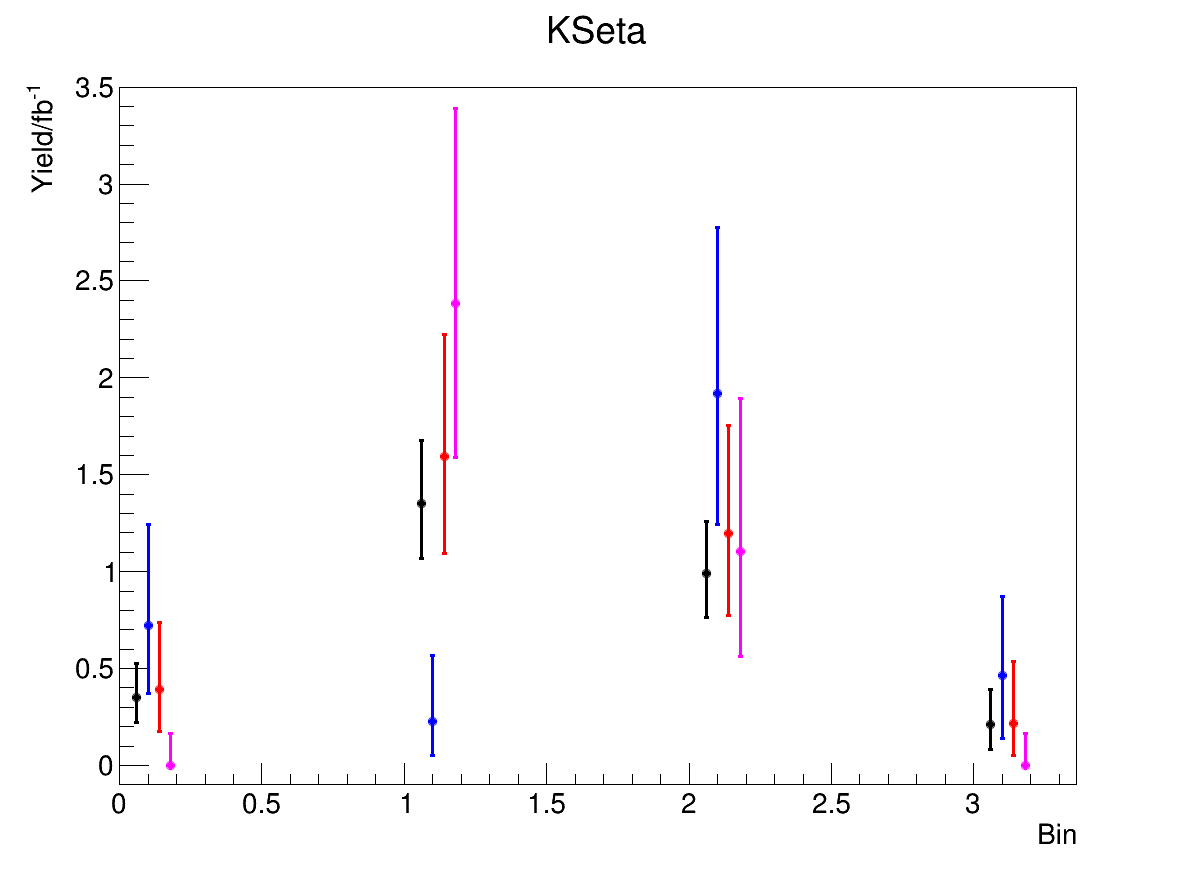

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSeta.pdf has been created


In [25]:
CompareDTYields("KSeta", "CP", -0.1, 3.5);

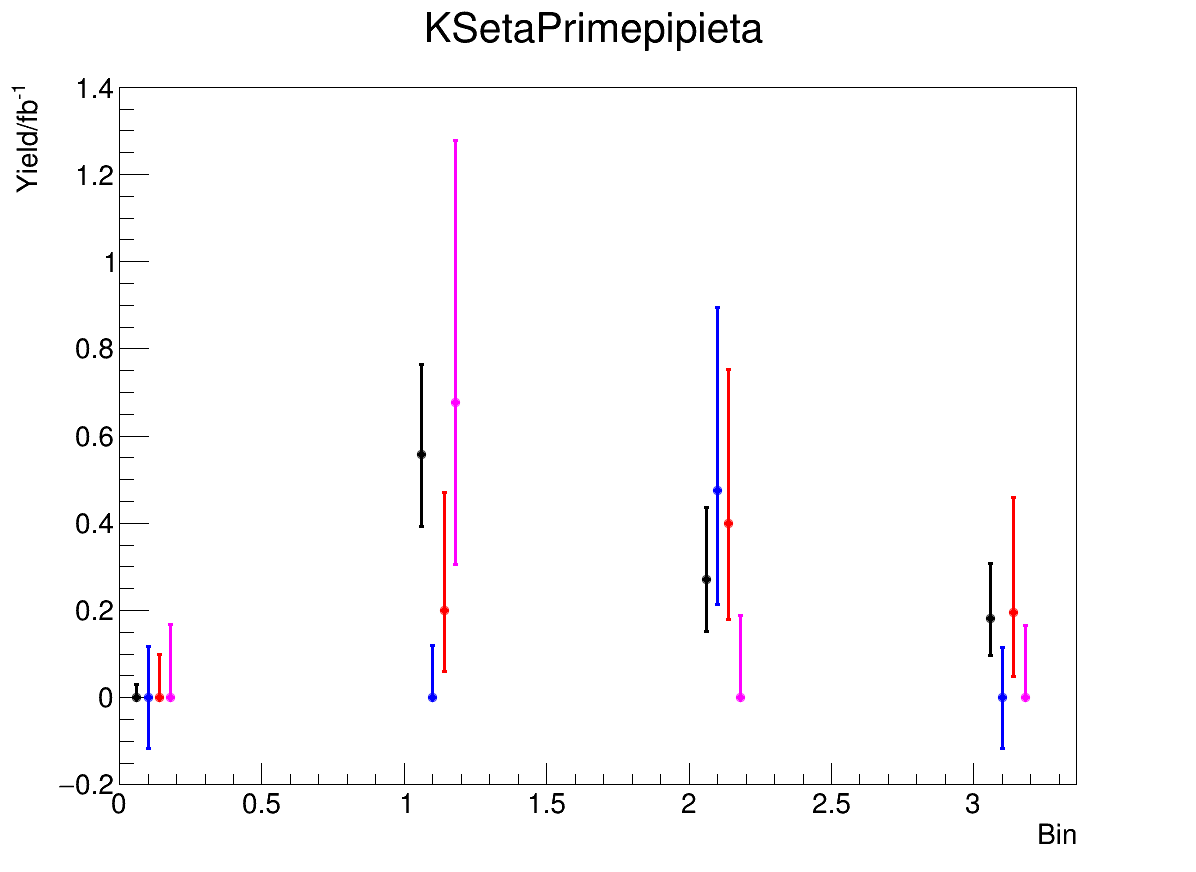

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSetaPrimepipieta.pdf has been created


In [26]:
CompareDTYields("KSetaPrimepipieta", "CP", -0.2, 1.4);

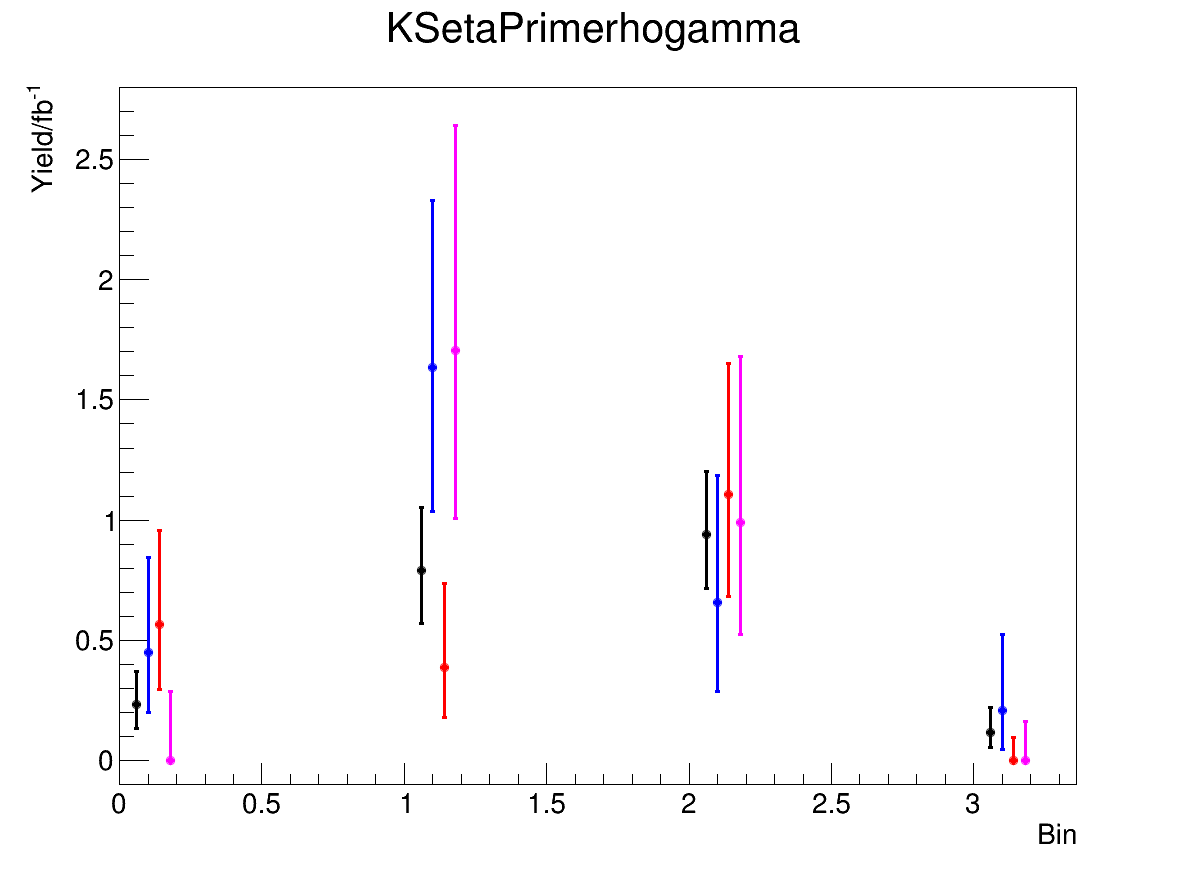

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSetaPrimerhogamma.pdf has been created


In [27]:
CompareDTYields("KSetaPrimerhogamma", "CP", -0.1, 2.8);

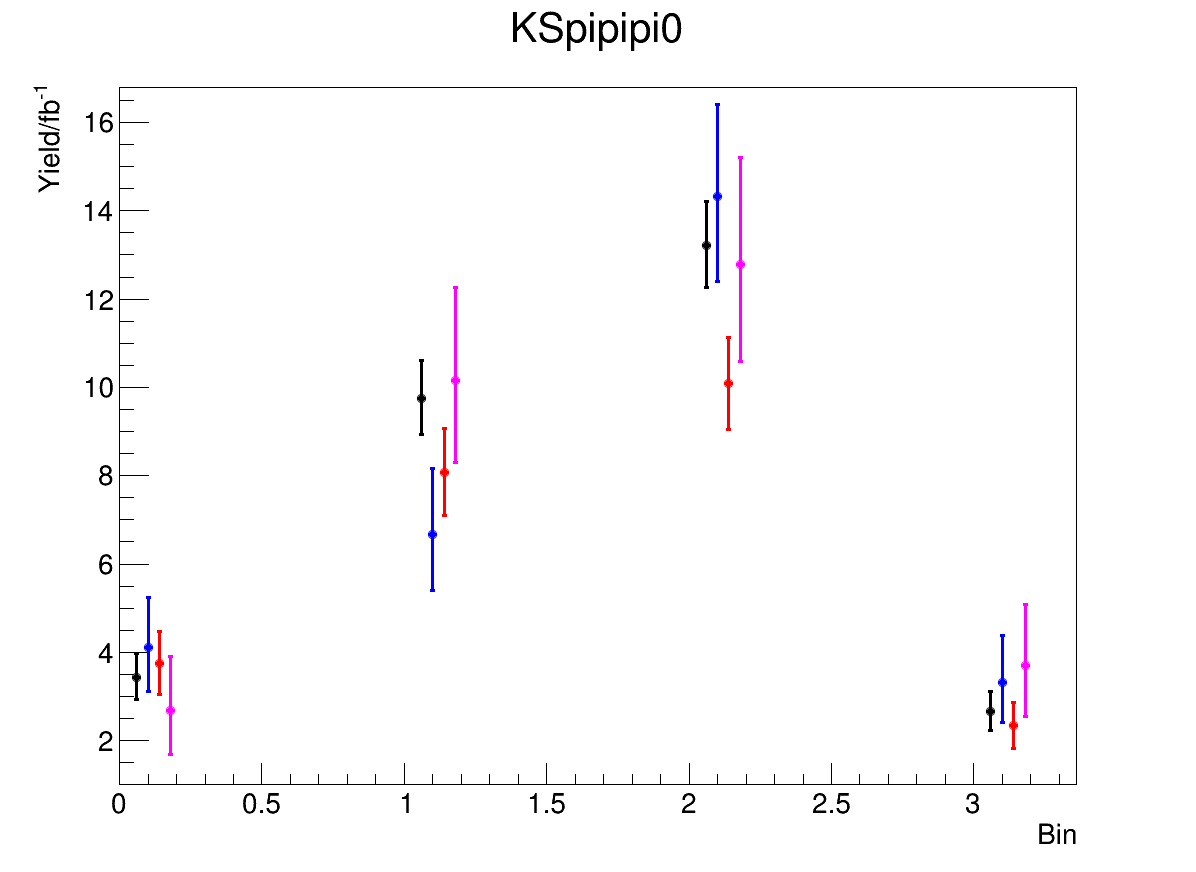

Info in <TCanvas::Print>: pdf file DT_yield_comparison_16_4_KSpipipi0.pdf has been created


In [28]:
CompareDTYields("KSpipipi0", "CP", 1.0, 16.8);